In [ ]:
#PartI Data Cleaning
import pandas as pd
import re
from bs4 import BeautifulSoup

# 1. Remove HTML tags using BeautifulSoup
def remove_html_tags(text: str) -> str:
    """
    Use BeautifulSoup to strip out HTML tags and keep only plain text.
    """
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ")

# 2. Remove noisy data (like URLs, email addresses, and long sequences of digits, e.g., phone numbers)
def remove_noise(text: str) -> str:
   
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\b\d{10,}\b', '', text)
    return text

# 3. Combined cleaning function: remove HTML tags, noisy data, convert to lowercase, and normalize whitespace.
def clean_text(text: str) -> str:
    """
    A combined cleaning function that:
    - Uses BeautifulSoup to remove HTML tags.
    - Removes URLs, email addresses, and phone numbers.
    - Converts the text to lowercase.
    - Strips extra whitespace and normalizes it.
    """
    text = remove_html_tags(text)
    text = remove_noise(text)
    
    text = text.lower()         # convert all text to lowercase
    text = text.strip()         # remove leading/trailing whitespace
    # Replace multiple spaces/newlines/tabs with a single space
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()


csv_files = [
    "salary_labelled_development_set.csv",
    "salary_labelled_test_set.csv",
    "seniority_labelled_development_set.csv",
    "seniority_labelled_test_set.csv",
    "work_arrangements_development_set.csv",
    "work_arrangements_test_set.csv",
    "unlabelled_development_set.csv"
]

# 4. Process each file: read, clean, remove duplicates, and save the cleaned version.
for file_name in csv_files:
    print(f"Cleaning {file_name} ...")

    df = pd.read_csv(file_name, encoding='utf-8', dtype=str)
    
    # Remove duplicate rows if any exist
    df.drop_duplicates(inplace=True)
    
    for col in df.columns:
        df[col] = df[col].apply(lambda x: clean_text(x) if isinstance(x, str) else x)
    
    cleaned_file_name = f"cleaned_{file_name}"
    df.to_csv(cleaned_file_name, index=False, encoding='utf-8')
    print(f"Saved cleaned data to {cleaned_file_name}\n")


Cohen’s κ = 0.940


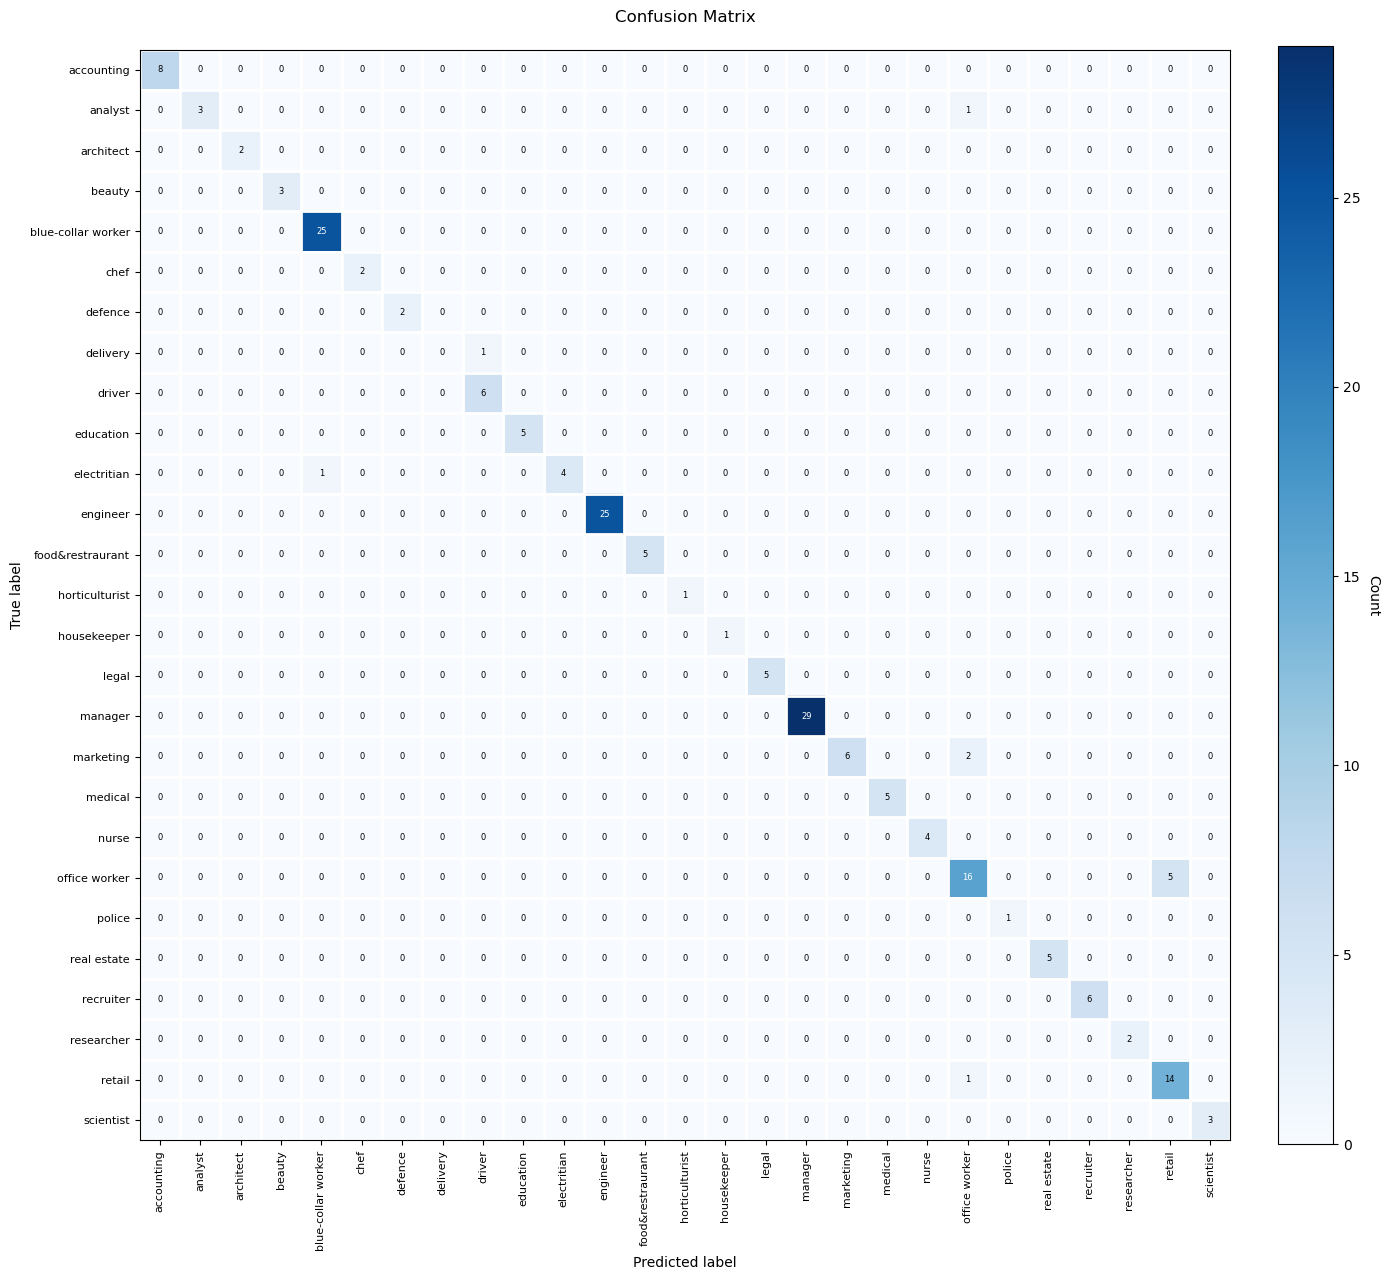

In [23]:
#PartII: Creating Own Label - IRR Calculation (Cohen’s κ) for Job-Keyword Label Annotation
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import cohen_kappa_score,accuracy_score, confusion_matrix



# 1. Read your CSV with an explicit encoding 
df = pd.read_csv("job_keyword_annotation.csv", 
                 encoding="latin1",      # or "cp1252", etc.
                 engine="python",        # more forgiving parser
                 )

# 2. Pull out and clean the two raters’ columns
r1 = df["job_keyword_rater_1"].astype(str).str.strip().str.lower()
r2 = df["job_keyword_rater_2"].astype(str).str.strip().str.lower()

# 3. Drop any rows where one rater is missing
mask = r1.notna() & r2.notna()
r1, r2 = r1[mask], r2[mask]

# 4. Encode your labels to integers
le = LabelEncoder()
le.fit(pd.concat([r1, r2], ignore_index=True))  # learn all categories
r1_enc = le.transform(r1)
r2_enc = le.transform(r2)

# 5. Compute Cohen’s κ
kappa = cohen_kappa_score(r1_enc, r2_enc)
print(f"Cohen’s κ = {kappa:.3f}")

# Load your annotations - adjust file path and column names as needed


# Compute metrics
kappa = cohen_kappa_score(r1, r2)
accuracy = accuracy_score(r1, r2)
labels = sorted(set(r1) | set(r2))


# Replace the following two lines with your actual confusion matrix and class labels
# For example, cm = np.array([[...], [...], ...])
# and labels = ['0', '1', '2', ..., '27']
cm = np.array(cm)            # your confusion matrix array
labels = list(map(str, labels))  # your list of class labels

import matplotlib.pyplot as plt
import numpy as np

# cm = your 28×28 confusion matrix numpy array
# labels = list of your 28 class names

fig, ax = plt.subplots(figsize=(14,14))
im = ax.imshow(cm,
               cmap='Blues',                # blue color scale
               interpolation='nearest',
               aspect='equal')

# add white grid lines
ax.set_xticks(np.arange(-.5, cm.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, cm.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

# labels
ax.set_xticks(np.arange(cm.shape[1]))
ax.set_yticks(np.arange(cm.shape[0]))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix', pad=20)

# colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Count', rotation=-90, va="bottom")

# annotations
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=6)

plt.tight_layout()
plt.show()



In [9]:
#PartIII - Create own label

import pandas as pd
import ast


SOURCE_CSV = 'cleaned_unlabelled_development_set.csv'
TARGET_CSV = 'skills_development.csv'
MAX_ROWS   = 300


# 1. Read the source CSV with fallback encodings

for enc in ('utf-8', 'latin-1', 'ISO-8859-1'):
    try:
        df = pd.read_csv(SOURCE_CSV, encoding=enc)
        break
    except UnicodeDecodeError:
        continue
else:
    raise RuntimeError(f"Failed to read {SOURCE_CSV} with any of the tried encodings.")


#2.coerce values into Python lists
skill_col = 'skills_true'

def to_list(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        s = val.strip()
        if s.startswith('[') and s.endswith(']'):
            try:
                return ast.literal_eval(s)
            except Exception:
                return []
    return []


# 3. Apply conversion and filter out empty lists

df[skill_col] = df[skill_col].apply(to_list)
df = df[df[skill_col].map(len) > 0]
df_dev = df.head(MAX_ROWS)


# 4. Select the columns you want to keep 
keep_cols = ['job_title', 'job_ad_details', 'nation_short_desc', skill_col]
keep_cols = [c for c in keep_cols if c in df_dev.columns]
df_dev = df_dev[keep_cols]


# 5. Save your development subset
df_dev.to_csv(TARGET_CSV, index=False, encoding='utf-8')
print(f"Saved {len(df_dev)} rows to {TARGET_CSV}")


print(df_dev.head(10))


Saved 300 rows to skills_development.csv
                                      job_title  \
0                         plastics die operator   
1                 el1 annual report coordinator   
3   enrolled endorsed nurses (een) - noosaville   
5               safety & sustainability manager   
6                                 php developer   
7                 service advisor / coordinator   
8      real estate receptionist & administrator   
9                               fund accountant   
11              draftsperson / project engineer   
12                       administration officer   

                                       job_ad_details nation_short_desc  \
0   a fantastic opportunity to work with a highly ...               aus   
1   we are looking for self starters who can proje...               aus   
3   we will offer: new starter reward bonus of $20...               aus   
5   at interactive we want the way we do business ...               aus   
6   this award-winning